# STURM-Flood Inference & Visualization Notebook

This notebook performs flood extent inference on Sentinel-1 and Sentinel-2 tiles using pretrained U-Net models, and computes metrics when ground-truth is available.

Models and datasets are available on Zenodo:
- Sentinel-1: [DOI:10.5281/zenodo.15189664](https://doi.org/10.5281/zenodo.15189664)
- Sentinel-2: [DOI:10.5281/zenodo.15189633](https://doi.org/10.5281/zenodo.15189633)
- Dataset: [DOI:10.5281/zenodo.12748982](https://doi.org/10.5281/zenodo.12748982)

# Import dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import sys


from tqdm import tqdm

import numpy as np

import pandas as pd
import requests

In [3]:
!git clone https://github.com/STURM-WEO/STURM-Flood.git repo

!cp -r repo/arch ./arch
!cp -r repo/utils ./utils
!ls
!ls arch

Cloning into 'repo'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 94 (delta 22), reused 53 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (94/94), 4.61 MiB | 11.93 MiB/s, done.
Resolving deltas: 100% (22/22), done.
arch  drive  repo  sample_data	utils
data_handling.py  losses.py  model.py  predictor.py  __pycache__  train.py


In [4]:
import os

print(os.getcwd())
print(os.path.exists("arch"))
print(os.path.exists("arch/model.py"))

/content
True
True


In [5]:
!pip install tensorflow-io

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 82.8 MB/s eta 0:00:00


In [6]:
import os

print(os.path.exists("/content/arch"))
print(os.path.exists("/content/arch/model.py"))

!ls -R /content/arch

True
True
/content/arch:
data_handling.py  losses.py  model.py  predictor.py  __pycache__  train.py

/content/arch/__pycache__:
losses.cpython-310.pyc	model.cpython-310.pyc
losses.cpython-311.pyc	model.cpython-311.pyc


In [7]:
import os
import sys

print("Current dir:", os.getcwd())
print("arch exists:", os.path.exists("/content/arch"))
print("model exists:", os.path.exists("/content/arch/model.py"))

print("\nFirst 5 sys.path:")
for p in sys.path[:5]:
    print(p)

Current dir: /content
arch exists: True
model exists: True

First 5 sys.path:
/content
/env/python
/usr/lib/python312.zip
/usr/lib/python3.12
/usr/lib/python3.12/lib-dynload


# Functions

In [8]:
# Add U-Net architecture path and import model
import os
import sys

arch_dir = os.path.abspath("arch")
print(arch_dir)
sys.path.append(arch_dir)
from model import unet_model

def rebuild_model(params):
    model = unet_model(
        n_classes=2,
        tile_width=params['input_shape'][0],
        tile_height=params['input_shape'][1],
        n_bands=params['input_shape'][2],
        n_blocks=params['n_blocks'],
        class_weight_list=[1, 1],
        normalize_inputs=False
    )
    model.load_weights(params['weights_path'])
    return model

/content/arch


/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl5mutex6unlockEv']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZNK10tensorflow4data11DatasetBase8FinalizeEPNS_15OpKernelContextESt8functionIFN4absl12lts_202

In [9]:
sys.path.append('./utils')
from utils.io import download_from_zenodo, extract_tarfile, extract_zipfile
from utils.inference_metrics import run_inference
from utils.visualization import save_visualizations

# Sturm-Flood dataset download

In [10]:
# Dataset URL and destination
#dataset_url = "https://zenodo.org/records/12748983/files/Dataset.zip"
dataset_dir = './STURM-Flood'
os.makedirs(dataset_dir, exist_ok=True)
dataset_zip_path = os.path.join(dataset_dir, "STURM-Flood.zip")

# Download dataset archive
#download_from_zenodo(dataset_url, dataset_zip_path)

# Extract ZIP archive
#extract_zipfile(dataset_zip_path, dataset_dir)


# U-Net setup

In [11]:
# Directories for pretrained models
s1_model_dir = './unet/sentinel1_model'
##s2_model_dir = './unet/sentinel2_model'
os.makedirs(s1_model_dir, exist_ok=True)
##os.makedirs(s2_model_dir, exist_ok=True)

# Download pretrained models from Zenodo
s1_model_url = "https://zenodo.org/records/15189665/files/S1_model.tar.gz"
##s2_model_url = "https://zenodo.org/records/15189634/files/S2_model.tar.gz"

s1_model_tar = os.path.join(s1_model_dir, 'model.tar.gz')
##s2_model_tar = os.path.join(s2_model_dir, 'model.tar.gz')

download_from_zenodo(s1_model_url, s1_model_tar)
##download_from_zenodo(s2_model_url, s2_model_tar)

# Extract the downloaded tar files
extract_tarfile(s1_model_tar, s1_model_dir)
##extract_tarfile(s2_model_tar, s2_model_dir)

In [12]:
# Model parameters and data directories
model_params = {
    'Sentinel-1': {
        'input_shape': (128, 128, 2),
        'n_blocks': 6,
        'weights_path': os.path.join(s1_model_dir, 'unet/1/model_weights.hdf5')
    },
    }


In [13]:
print(model_params['Sentinel-1'])

{'input_shape': (128, 128, 2), 'n_blocks': 6, 'weights_path': './unet/sentinel1_model/unet/1/model_weights.hdf5'}


In [14]:
# Rebuild models
s1_model = rebuild_model(model_params['Sentinel-1'])
##s2_model = rebuild_model(model_params['Sentinel-2'])

# Inference

## Data and metadata

In [15]:
# Define directories for composites, masks, and output predictions
composite_dirs = {
    'Sentinel-1': "/content/drive/MyDrive/GEE_Flood_Export",

}

with_gt = True
mask_dirs = {
    'Sentinel-1': "/content/drive/MyDrive/GEEmask",
}

output_dir = './inference_results'
visualization_dir = './tile_visualizations'
os.makedirs(output_dir, exist_ok=True)
os.makedirs(visualization_dir, exist_ok=True)

# Load metadata
##s1_metadata_path = "./STURM-Flood/Dataset/Sentinel1_metadata.csv"
##s2_metadata_path = "./STURM-Flood/Dataset/Sentinel2_metadata.csv"

##s1_metadata = pd.read_csv(s1_metadata_path)
##s2_metadata = pd.read_csv(s2_metadata_path)

# Sample 10 tiles for quick testing (adjust as needed)
##s1_test_df = s1_metadata.sample(n=5, random_state=42).reset_index(drop=True)
##s2_test_df = s2_metadata.sample(n=5, random_state=42).reset_index(drop=True)


##print(f"Sentinel-2: {len(s2_test_df)} test tiles loaded.")
s1_test_df = pd.DataFrame({
    "tile_id": ["S1_PostFlood_VV_VH_10m.tif"]
})

print("Sentinel-1: 1 tile loaded.")
print(f"Sentinel-1: {len(s1_test_df)} test tiles loaded.")


Sentinel-1: 1 tile loaded.
Sentinel-1: 1 test tiles loaded.


Band names: ('VV', 'VH')


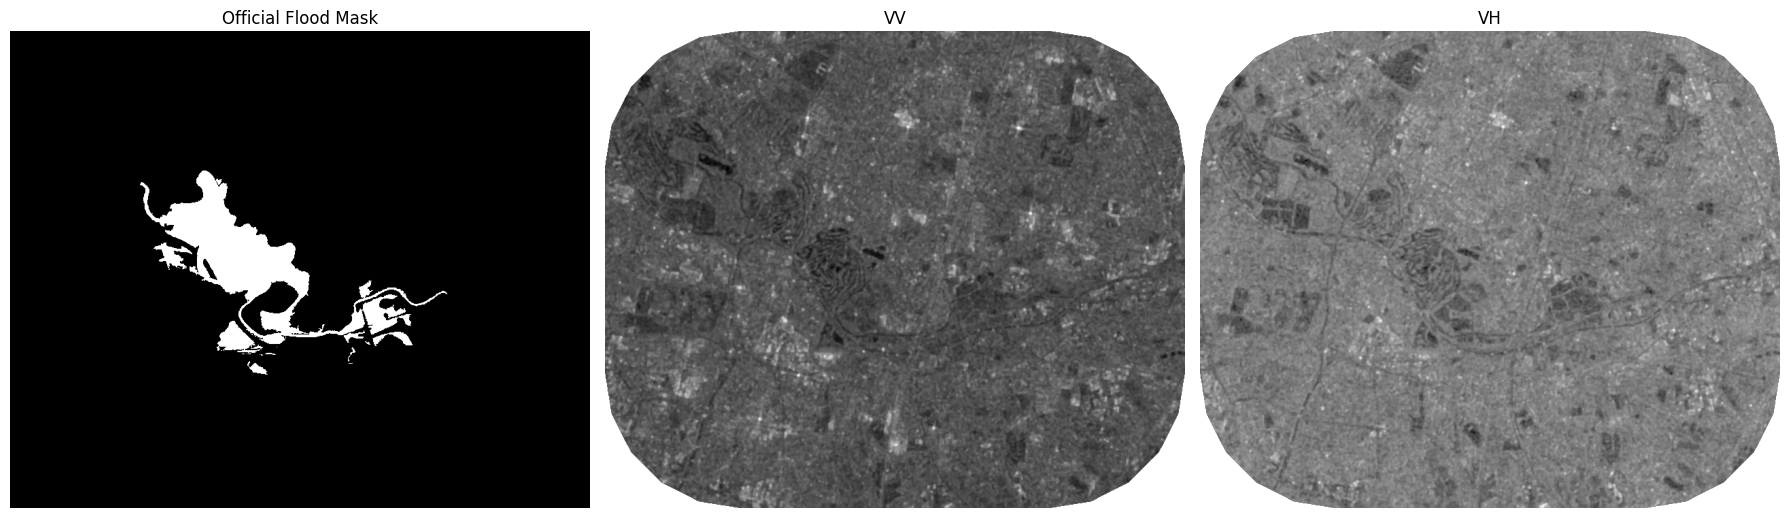

In [16]:
import rasterio
import matplotlib.pyplot as plt

image_path = "/content/drive/MyDrive/GEE_Flood_Export/Sentinel1_VV_VH_Filtered_2025_EPSG27700_raduis20.tif"
mask_path = "/content/drive/MyDrive/GEEmask/Flood2025_EPSG27700_raduis20.tif"


with rasterio.open(image_path) as src:
    vv = src.read(1)
    vh = src.read(2)
    print("Band names:", src.descriptions)

with rasterio.open(mask_path) as src:
    mask = src.read(1)

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(mask, cmap="gray")
plt.title("Official Flood Mask")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(vv, cmap="gray")
plt.title("VV")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(vh, cmap="gray")
plt.title("VH")
plt.axis("off")

plt.tight_layout()
plt.show()

Shape: (701, 853)
Unique values: [0 1]
Min: 0
Max: 1


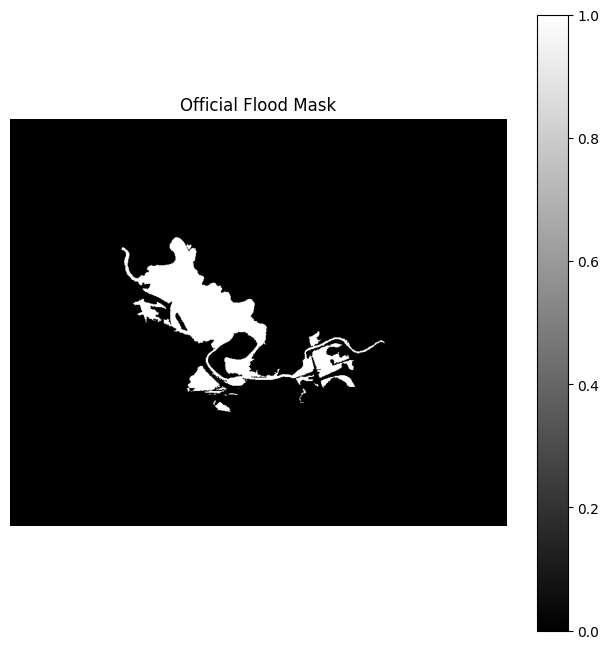

In [17]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

mask_path = "/content/drive/MyDrive/GEEmask/Flood2025_EPSG27700_raduis20.tif"

with rasterio.open(mask_path) as src:
    mask = src.read(1)

print("Shape:", mask.shape)
print("Unique values:", np.unique(mask))
print("Min:", mask.min())
print("Max:", mask.max())

plt.figure(figsize=(8,8))
plt.imshow(mask, cmap="gray")
plt.title("Official Flood Mask")
plt.colorbar()
plt.axis("off")
plt.show()

In [18]:
unique, counts = np.unique(mask, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Value {u}: {c} pixels")

Value 0: 570086 pixels
Value 1: 27867 pixels


In [19]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    jaccard_score
)
import numpy as np

def calculate_metrics(gt, pred):
    gt = gt.astype(np.uint8)
    pred = pred.astype(np.uint8)

    f1 = f1_score(gt.flatten(), pred.flatten(), zero_division=0)
    precision = precision_score(gt.flatten(), pred.flatten(), zero_division=0)
    recall = recall_score(gt.flatten(), pred.flatten(), zero_division=0)
    iou = jaccard_score(gt.flatten(), pred.flatten(), zero_division=0)

    tp = np.sum((pred == 1) & (gt == 1))
    tn = np.sum((pred == 0) & (gt == 0))
    fp = np.sum((pred == 1) & (gt == 0))
    fn = np.sum((pred == 0) & (gt == 1))

    return {
        "F1": f1,
        "Precision": precision,
        "Recall": recall,
        "IoU": iou,
        "TP": int(tp),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn)
    }

In [20]:
!pip install remotezip

In [21]:
from remotezip import RemoteZip
import os

url = "https://zenodo.org/records/12748983/files/Dataset.zip?download=1"
out_dir = "/content/sturm_sample"
os.makedirs(out_dir, exist_ok=True)

with RemoteZip(url) as rz:
    names = rz.namelist()

    print("First 30 paths in the folder")
    for name in names[:30]:
        print(name)

    s1_tiles = [
        name for name in names
        if "Sentinel1/S1/" in name
        and name.lower().endswith(".tif")
    ]

    if not s1_tiles:
        raise RuntimeError("non- Sentinel-1 tiles")

    tile_name = s1_tiles[0]
    filename = os.path.basename(tile_name)
    tile_path = os.path.join(out_dir, filename)

    with open(tile_path, "wb") as f:
        f.write(rz.read(tile_name))

print("One Tile is downloaded")
print(tile_path)
from remotezip import RemoteZip

url = "https://zenodo.org/records/12748983/files/Dataset.zip?download=1"

with RemoteZip(url) as rz:
    names = rz.namelist()

    s1_tiles = [n for n in names if "Dataset/Sentinel1/S1/" in n and n.endswith(".tif")]

    print("Tiles:", len(s1_tiles))
    print()

    for i in range(10):
        print(s1_tiles[i])
        from remotezip import RemoteZip
import os

url = "https://zenodo.org/records/12748983/files/Dataset.zip?download=1"
out_dir = "/content/sturm_sample"
os.makedirs(out_dir, exist_ok=True)

with RemoteZip(url) as rz:
    names = rz.namelist()

    s1_tiles = [
        n for n in names
        if n.startswith("Dataset/Sentinel1/S1/")
        and n.lower().endswith(".tif")
    ]

    floodmaps = [
        n for n in names
        if n.startswith("Dataset/Sentinel1/Floodmaps/")
        and n.lower().endswith(".tif")
    ]


    tile_name = s1_tiles[0]
    filename = os.path.basename(tile_name)


    mask_name = next(
        (
            n for n in floodmaps
            if os.path.basename(n) == filename
        ),
        None
    )

    if mask_name is None:
        raise RuntimeError(
            f"non-mask: {filename}"
        )

    tile_path = os.path.join(out_dir, filename)
    mask_path = os.path.join(out_dir, "mask_" + filename)

    with open(tile_path, "wb") as f:
        f.write(rz.read(tile_name))

    with open(mask_path, "wb") as f:
        f.write(rz.read(mask_name))


print(tile_path)


print(mask_path)
import rasterio

with rasterio.open(tile_path) as src:
    print("Tile shape:", src.height, src.width)
    print("Tile bands:", src.count)
    print("Descriptions:", src.descriptions)

with rasterio.open(mask_path) as src:
    print("Mask shape:", src.height, src.width)
    print("Mask bands:", src.count)
    import numpy as np
import rasterio

with rasterio.open(tile_path) as src:
    input_data = src.read(
        out_dtype=np.float32
    ).transpose(1, 2, 0)

prediction_probs = s1_model.predict(
    np.expand_dims(input_data, axis=0),
    verbose=0
)[0]

binary_prediction = (
    prediction_probs[:, :, 1] > 0.5
).astype(np.uint8)

with rasterio.open(mask_path) as src:
    gt = (src.read(1) > 0).astype(np.uint8)

print(calculate_metrics(gt, binary_prediction))


First 30 paths in the folder
Dataset/Sentinel1/
Dataset/Sentinel1/Floodmaps/
Dataset/Sentinel1/Floodmaps/EMSR260_02VIADANA_2_1_2_2.tif
Dataset/Sentinel1/Floodmaps/EMSR260_02VIADANA_2_2_2_1.tif
Dataset/Sentinel1/Floodmaps/EMSR260_02VIADANA_2_2_2_2.tif
Dataset/Sentinel1/Floodmaps/EMSR260_02VIADANA_3_2_1_2.tif
Dataset/Sentinel1/Floodmaps/EMSR260_09RUBIERA_1_1_2_2.tif
Dataset/Sentinel1/Floodmaps/EMSR260_09RUBIERA_1_2_2_1.tif
Dataset/Sentinel1/Floodmaps/EMSR260_09RUBIERA_1_2_2_2.tif
Dataset/Sentinel1/Floodmaps/EMSR260_09RUBIERA_1_3_2_1.tif
Dataset/Sentinel1/Floodmaps/EMSR260_09RUBIERA_2_1_1_2.tif
Dataset/Sentinel1/Floodmaps/EMSR260_09RUBIERA_2_1_2_2.tif
Dataset/Sentinel1/Floodmaps/EMSR261_01HANNOVER_01_01_2_2.tif
Dataset/Sentinel1/Floodmaps/EMSR261_01HANNOVER_01_02_2_1.tif
Dataset/Sentinel1/Floodmaps/EMSR261_01HANNOVER_01_02_2_2.tif
Dataset/Sentinel1/Floodmaps/EMSR261_01HANNOVER_01_03_2_1.tif
Dataset/Sentinel1/Floodmaps/EMSR261_01HANNOVER_01_03_2_2.tif
Dataset/Sentinel1/Floodmaps/EMSR261_01

In [22]:
from remotezip import RemoteZip
import os
import rasterio
import numpy as np

url = "https://zenodo.org/records/12748983/files/Dataset.zip?download=1"

out_dir = "/content/sturm_sample"
os.makedirs(out_dir, exist_ok=True)

with RemoteZip(url) as rz:
    names = rz.namelist()


    s1_tiles = [
        name for name in names
        if name.startswith("Dataset/Sentinel1/S1/")
        and name.lower().endswith(".tif")
    ]

    if len(s1_tiles) == 0:
        raise RuntimeError("No Sentinel-1 tiles were found.")


    tile_name = s1_tiles[0]
    tile_path = os.path.join(
        out_dir,
        os.path.basename(tile_name)
    )


    with open(tile_path, "wb") as f:
        f.write(rz.read(tile_name))

print("Selected file:")
print(tile_name)

print("\nDownloaded to:")
print(tile_path)


with rasterio.open(tile_path) as src:
    print("\n===== Raster information =====")
    print("Number of bands:", src.count)
    print("Descriptions:", src.descriptions)
    print("Indexes:", src.indexes)
    print("Shape:", src.height, src.width)
    print("Dtypes:", src.dtypes)
    print("CRS:", src.crs)
    print("Dataset tags:", src.tags())

    image = src.read(out_dtype=np.float32)

    for band_index in src.indexes:
        band = image[band_index - 1]

        print(f"\nBand {band_index}")
        print("Description:", src.descriptions[band_index - 1])
        print("Tags:", src.tags(band_index))
        print("Minimum:", np.nanmin(band))
        print("Maximum:", np.nanmax(band))
        print("Mean:", np.nanmean(band))

Selected file:
Dataset/Sentinel1/S1/EMSR260_02VIADANA_2_1_2_2.tif

Downloaded to:
/content/sturm_sample/EMSR260_02VIADANA_2_1_2_2.tif

===== Raster information =====
Number of bands: 2
Descriptions: (None, None)
Indexes: (1, 2)
Shape: 128 128
Dtypes: ('float32', 'float32')
CRS: EPSG:32632
Dataset tags: {'AREA_OR_POINT': 'Area'}

Band 1
Description: None
Tags: {}
Minimum: 0.11230688
Maximum: 0.8355912
Mean: 0.47518998

Band 2
Description: None
Tags: {}
Minimum: -0.14516059
Maximum: 0.5789371
Mean: 0.3155778


In [23]:
import os
import numpy as np
import rasterio
from tqdm import tqdm


def run_inference_large_image(
    image_path,
    mask_path,
    model,
    output_dir,
    score_threshold=0.5,
    with_gt=True
):
    os.makedirs(output_dir, exist_ok=True)

    # -------------------------------------------------------
    # 1) Read Sentien-1
    # -------------------------------------------------------
    with rasterio.open(image_path) as src:
        image = src.read(
            out_dtype=np.float32
        ).transpose(1, 2, 0)

        profile = src.profile.copy()

    # -------------------------------------------------------

    # -------------------------------------------------------
    valid_data_mask = np.all(
        np.isfinite(image),
        axis=2
    )

    # -------------------------------------------------------
    # 3) Normalization
    #   from -30 to 10
    # -------------------------------------------------------
    image = (image + 30.0) / 40.0
    image = np.clip(image, 0.0, 1.0)


    image = np.nan_to_num(
        image,
        nan=0.0,
        posinf=1.0,
        neginf=0.0
    )

    # -------------------------------------------------------

    # -------------------------------------------------------
    print("\n===== Image after normalization =====")

    for i, name in enumerate(["VV", "VH"]):
        band = image[:, :, i]
        valid = band[valid_data_mask]

        print(f"\n{name}")
        print("Min   :", valid.min())
        print("Median:", np.median(valid))
        print("Mean  :", valid.mean())
        print("Max   :", valid.max())

    height, width, bands = image.shape

    if bands != 2:
        raise ValueError(
            f"Expected 2 bands, found {bands}"
        )

    # -------------------------------------------------------

    # -------------------------------------------------------
    prob_map = np.zeros(
        (height, width, 2),
        dtype=np.float32
    )

    count_map = np.zeros(
        (height, width),
        dtype=np.float32
    )

    tile_size = 128

    # -------------------------------------------------------
    # 6) divided the image to 128x128 pixles
    # -------------------------------------------------------
    for row in tqdm(
        range(0, height, tile_size),
        desc="Rows"
    ):
        for col in range(0, width, tile_size):

            tile = image[
                row:row + tile_size,
                col:col + tile_size,
                :
            ]

            tile_h, tile_w, _ = tile.shape


            padded = np.zeros(
                (tile_size, tile_size, 2),
                dtype=np.float32
            )

            padded[
                :tile_h,
                :tile_w,
                :
            ] = tile

            #
            prediction = model.predict(
                np.expand_dims(padded, axis=0),
                verbose=0
            )[0]

            #
            prediction = prediction[
                :tile_h,
                :tile_w,
                :
            ]

            prob_map[
                row:row + tile_h,
                col:col + tile_w,
                :
            ] += prediction

            count_map[
                row:row + tile_h,
                col:col + tile_w
            ] += 1

    # -------------------------------------------------------
    #
    # -------------------------------------------------------
    count_map[count_map == 0] = 1

    prob_map = prob_map / count_map[:, :, None]

    #
    prob_map[~valid_data_mask, :] = 0

    # -------------------------------------------------------
    # 8)
    # -------------------------------------------------------
    binary_prediction = (
        prob_map[:, :, 1] > score_threshold
    ).astype(np.uint8)

    binary_prediction[~valid_data_mask] = 0

    # -------------------------------------------------------
    #
    # -------------------------------------------------------
    prob_output_path = os.path.join(
        output_dir,
        "sentinel1_probs.tif"
    )

    binary_output_path = os.path.join(
        output_dir,
        "sentinel1_binary.tif"
    )

    # -------------------------------------------------------
    #
    # -------------------------------------------------------
    prob_profile = profile.copy()
    prob_profile.update(
        count=2,
        dtype=rasterio.float32,
        nodata=0.0
    )

    with rasterio.open(
        prob_output_path,
        "w",
        **prob_profile
    ) as dst:
        dst.write(
            prob_map.transpose(2, 0, 1)
        )

    # -------------------------------------------------------
    #
    # -------------------------------------------------------
    binary_profile = profile.copy()
    binary_profile.update(
        count=1,
        dtype=rasterio.uint8,
        nodata=0
    )

    with rasterio.open(
        binary_output_path,
        "w",
        **binary_profile
    ) as dst:
        dst.write(
            binary_prediction,
            1
        )

    print(
        "\nSaved probability map:",
        prob_output_path
    )

    print(
        "Saved binary flood map:",
        binary_output_path
    )

    # -------------------------------------------------------
    #
    # -------------------------------------------------------
    if with_gt:
        if mask_path is None:
            raise ValueError(
                "mask_path is required when with_gt=True"
            )

        with rasterio.open(mask_path) as src:
            gt = src.read(1)

        if gt.shape != binary_prediction.shape:
            raise ValueError(
                f"Ground truth shape {gt.shape} "
                f"does not match prediction shape "
                f"{binary_prediction.shape}"
            )

        gt = (gt > 0).astype(np.uint8)


        gt_eval = gt[valid_data_mask]
        pred_eval = binary_prediction[valid_data_mask]

        return calculate_metrics(
            gt_eval,
            pred_eval
        )

    return None

In [24]:
image_path = "/content/drive/MyDrive/GEE_Flood_Export/Sentinel1_VV_VH_Filtered_2025_EPSG27700_raduis20.tif"
mask_path = "/content/drive/MyDrive/GEEmask/Flood2025_EPSG27700_raduis20.tif"
metrics = run_inference_large_image(
    image_path=image_path,
    mask_path=mask_path,
    model=s1_model,
    output_dir="/content/inference_results",
    score_threshold=0.5,
    with_gt=True
)

print(metrics)


===== Image after normalization =====

VV
Min   : 0.12813596
Median: 0.5279933
Mean  : 0.5350018
Max   : 1.0

VH
Min   : 0.0
Median: 0.35705292
Mean  : 0.35239738
Max   : 0.9770306


Rows: 100%|██████████| 6/6 [00:48<00:00,  8.15s/it]



Saved probability map: /content/inference_results/sentinel1_probs.tif
Saved binary flood map: /content/inference_results/sentinel1_binary.tif
{'F1': 0.08255922607596328, 'Precision': 0.1763117736823571, 'Recall': 0.05389887680769369, 'IoU': np.float64(0.04305698887742231), 'TP': 1502, 'TN': 526810, 'FP': 7017, 'FN': 26365}


In [26]:
import numpy as np
import rasterio
from scipy.ndimage import distance_transform_edt

image_path = "/content/drive/MyDrive/GEE_Flood_Export/Sentinel1_VV_VH_Filtered_2025_EPSG27700_raduis20.tif"
mask_path = "/content/drive/MyDrive/GEEmask/Flood2025_EPSG27700_raduis20.tif"
prediction_path = "/content/inference_results/sentinel1_binary.tif"


with rasterio.open(mask_path) as src:
    gt = (src.read(1) > 0).astype(np.uint8)

with rasterio.open(prediction_path) as src:
    pred = (src.read(1) > 0).astype(np.uint8)


with rasterio.open(image_path) as src:
    s1 = src.read(out_dtype=np.float32)

valid_data = np.all(np.isfinite(s1), axis=0)


if gt.shape != pred.shape:
    raise ValueError(
        f"Shape mismatch: GT={gt.shape}, prediction={pred.shape}"
    )


distance_from_flood = distance_transform_edt(
    gt == 0,
    sampling=10.0
)

# evalution with buffer 50 m
evaluation_area = (
    (distance_from_flood <= 50.0)
    & valid_data
)


gt_50m = gt[evaluation_area]
pred_50m = pred[evaluation_area]


metrics_50m = calculate_metrics(
    gt_50m,
    pred_50m
)

print("===== Official flood + 50 m buffer =====")
print("Evaluated pixels:", evaluation_area.sum())
print("Official flood pixels:", gt_50m.sum())
print("Predicted flood pixels:", pred_50m.sum())
print("Official flood ratio:", gt_50m.mean())
print("Predicted flood ratio:", pred_50m.mean())

print("\nMetrics inside 50 m buffer:")
print(metrics_50m)

===== Official flood + 50 m buffer =====
Evaluated pixels: 43714
Official flood pixels: 27867
Predicted flood pixels: 1613
Official flood ratio: 0.637484558722606
Predicted flood ratio: 0.036898933979960656

Metrics inside 50 m buffer:
{'F1': 0.10189959294436907, 'Precision': 0.9311841289522629, 'Recall': 0.05389887680769369, 'IoU': np.float64(0.053685038244334835), 'TP': 1502, 'TN': 15736, 'FP': 111, 'FN': 26365}


## Run Inference and collect metrics if ground-truth is available

In [ ]:

# Run inference and collect metrics

score_threshold = 0.5
results = []

for dataset, df, model in zip( ['Sentinel-1'],
    [s1_test_df,],
    [s1_model,]
):
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {dataset}"):
        tile = row['tile_id']
        metrics = run_inference(tile, dataset, model, composite_dirs, mask_dirs, output_dir, score_threshold, with_gt)
        if metrics:
            metrics['tile_id'] = tile
            metrics['Dataset'] = dataset
            results.append(metrics)

if with_gt:
    # Save evaluation results
    results_df = pd.DataFrame(results)
    results_df.to_csv('inference_metrics.csv', index=False)
    print("Inference completed. Metrics saved to 'inference_metrics.csv'.")
else:
    print("Inference completed. No metrics saved as 'with_gt' is set to False.")


Processing Sentinel-1:   0%|          | 0/1 [00:14<?, ?it/s]


InvalidArgumentError: Graph execution error:

Detected at node functional_1/concatenate_1/concat defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  File "/usr/local/lib/python3.12/

## Visualize results and save visualizations

In [ ]:

# Save visualizations

if with_gt:
    # Save visualizations with GT
    save_visualizations(results_df[results_df['Dataset'] == 'Sentinel-1'],
                        'Sentinel-1', visualization_dir,composite_dirs, output_dir, mask_dirs, is_s2=False, with_gt=True, show_inline=True)
    save_visualizations(results_df[results_df['Dataset'] == 'Sentinel-2'],
                        'Sentinel-2', visualization_dir,composite_dirs, output_dir, mask_dirs, is_s2=True, with_gt=True, show_inline=True)
    print("Visualizations saved to folder:", visualization_dir)
else:
    # Save visualizations without GT
    save_visualizations(s1_test_df, 'Sentinel-1', visualization_dir, composite_dirs, output_dir, mask_dirs, is_s2=False, with_gt=False, show_inline=True,)
    ##save_visualizations(s2_test_df, 'Sentinel-2', visualization_dir, composite_dirs, output_dir, mask_dirs, is_s2=True, with_gt=False, show_inline=True,)
    print("Visualizations saved to folder:", visualization_dir)

In [27]:
import numpy as np
import rasterio
from scipy.ndimage import distance_transform_edt

prob_path = "/content/inference_results/sentinel1_probs.tif"
image_path = "/content/drive/MyDrive/GEE_Flood_Export/Sentinel1_VV_VH_Filtered_2025_EPSG27700_raduis20.tif"
mask_path = "/content/drive/MyDrive/GEEmask/Flood2025_EPSG27700_raduis20.tif"
# Band 2
with rasterio.open(prob_path) as src:
    water_prob = src.read(2)


with rasterio.open(mask_path) as src:
    gt = (src.read(1) > 0).astype(np.uint8)


with rasterio.open(image_path) as src:
    s1 = src.read(out_dtype=np.float32)

valid_data = np.all(np.isfinite(s1), axis=0)
valid_prob = np.isfinite(water_prob)

# buffer 50 with every pixle 10m
distance_from_flood = distance_transform_edt(
    gt == 0,
    sampling=10.0
)

evaluation_area = (
    (distance_from_flood<= 50.0)
    & valid_data
    & valid_prob
)

gt_eval = gt[evaluation_area]
prob_eval = water_prob[evaluation_area]

print("Evaluated pixels:", gt_eval.size)
print("Official flood pixels:", gt_eval.sum())

best = None

for threshold in np.arange(0.10, 0.61, 0.02):
    pred_eval = (prob_eval > threshold).astype(np.uint8)
    metrics = calculate_metrics(gt_eval, pred_eval)

    row = {
        "threshold": round(float(threshold), 2),
        **metrics
    }

    if best is None or metrics["F1"] > best["F1"]:
        best = row

    print(
        f"T={threshold:.2f} | "
        f"F1={metrics['F1']:.4f} | "
        f"Precision={metrics['Precision']:.4f} | "
        f"Recall={metrics['Recall']:.4f} | "
        f"IoU={metrics['IoU']:.4f}"
    )

print("\n===== Best threshold =====")
print(best)

Evaluated pixels: 43714
Official flood pixels: 27867
T=0.10 | F1=0.7786 | Precision=0.6375 | Recall=1.0000 | IoU=0.6375
T=0.12 | F1=0.7786 | Precision=0.6375 | Recall=1.0000 | IoU=0.6375
T=0.14 | F1=0.7786 | Precision=0.6375 | Recall=1.0000 | IoU=0.6375
T=0.16 | F1=0.7786 | Precision=0.6375 | Recall=1.0000 | IoU=0.6375
T=0.18 | F1=0.7786 | Precision=0.6375 | Recall=1.0000 | IoU=0.6375
T=0.20 | F1=0.7786 | Precision=0.6375 | Recall=1.0000 | IoU=0.6375
T=0.22 | F1=0.7786 | Precision=0.6375 | Recall=1.0000 | IoU=0.6375
T=0.24 | F1=0.7786 | Precision=0.6375 | Recall=1.0000 | IoU=0.6375
T=0.26 | F1=0.7786 | Precision=0.6375 | Recall=1.0000 | IoU=0.6375
T=0.28 | F1=0.7786 | Precision=0.6375 | Recall=1.0000 | IoU=0.6375
T=0.30 | F1=0.7786 | Precision=0.6375 | Recall=1.0000 | IoU=0.6375
T=0.32 | F1=0.7791 | Precision=0.6382 | Recall=0.9999 | IoU=0.6382
T=0.34 | F1=0.7822 | Precision=0.6457 | Recall=0.9920 | IoU=0.6423
T=0.36 | F1=0.6445 | Precision=0.7599 | Recall=0.5596 | IoU=0.4755
T=0.38 | 

In [28]:
print("dtype:", water_prob.dtype)
print("min:", water_prob.min(), "max:", water_prob.max())
print("unique sample:", np.unique(water_prob)[:20])

dtype: float32
min: 0.0 max: 0.61756706
unique sample: [0.         0.26750335 0.2692401  0.26946223 0.26983154 0.2711205
 0.27114344 0.27140746 0.27164277 0.2717579  0.27212    0.27232942
 0.27253956 0.2732063  0.2733125  0.274078   0.27429098 0.2743917
 0.27507454 0.27512655]


In [29]:
import rasterio

with rasterio.open("/content/drive/MyDrive/GEE_Flood_Export/Sentinel1_VV_VH_Filtered_2025_EPSG27700_raduis20.tif") as src:
    print(src.descriptions)

('VV', 'VH')


In [30]:
print(np.unique(mask))

[0 1]


In [31]:
with rasterio.open(mask_path) as src:
    print("CRS:", src.crs)
    print("Projected:", src.crs.is_projected)
    print("Geographic:", src.crs.is_geographic)
    print("Pixel width:", abs(src.transform.a))
    print("Pixel height:", abs(src.transform.e))

CRS: EPSG:27700
Projected: True
Geographic: False
Pixel width: 10.0
Pixel height: 10.0


===== Official flood + 50 m buffer evaluation =====
Threshold: 0.34
Evaluated pixels: 43714

Confusion matrix counts
TP: 27643
TN: 677
FP: 15170
FN: 224

Metrics
Precision : 0.6456683717562423
Recall    : 0.991961818638533
F1        : 0.7822014714204867
IoU       : 0.642307781676232
Accuracy  : 0.647847371551448


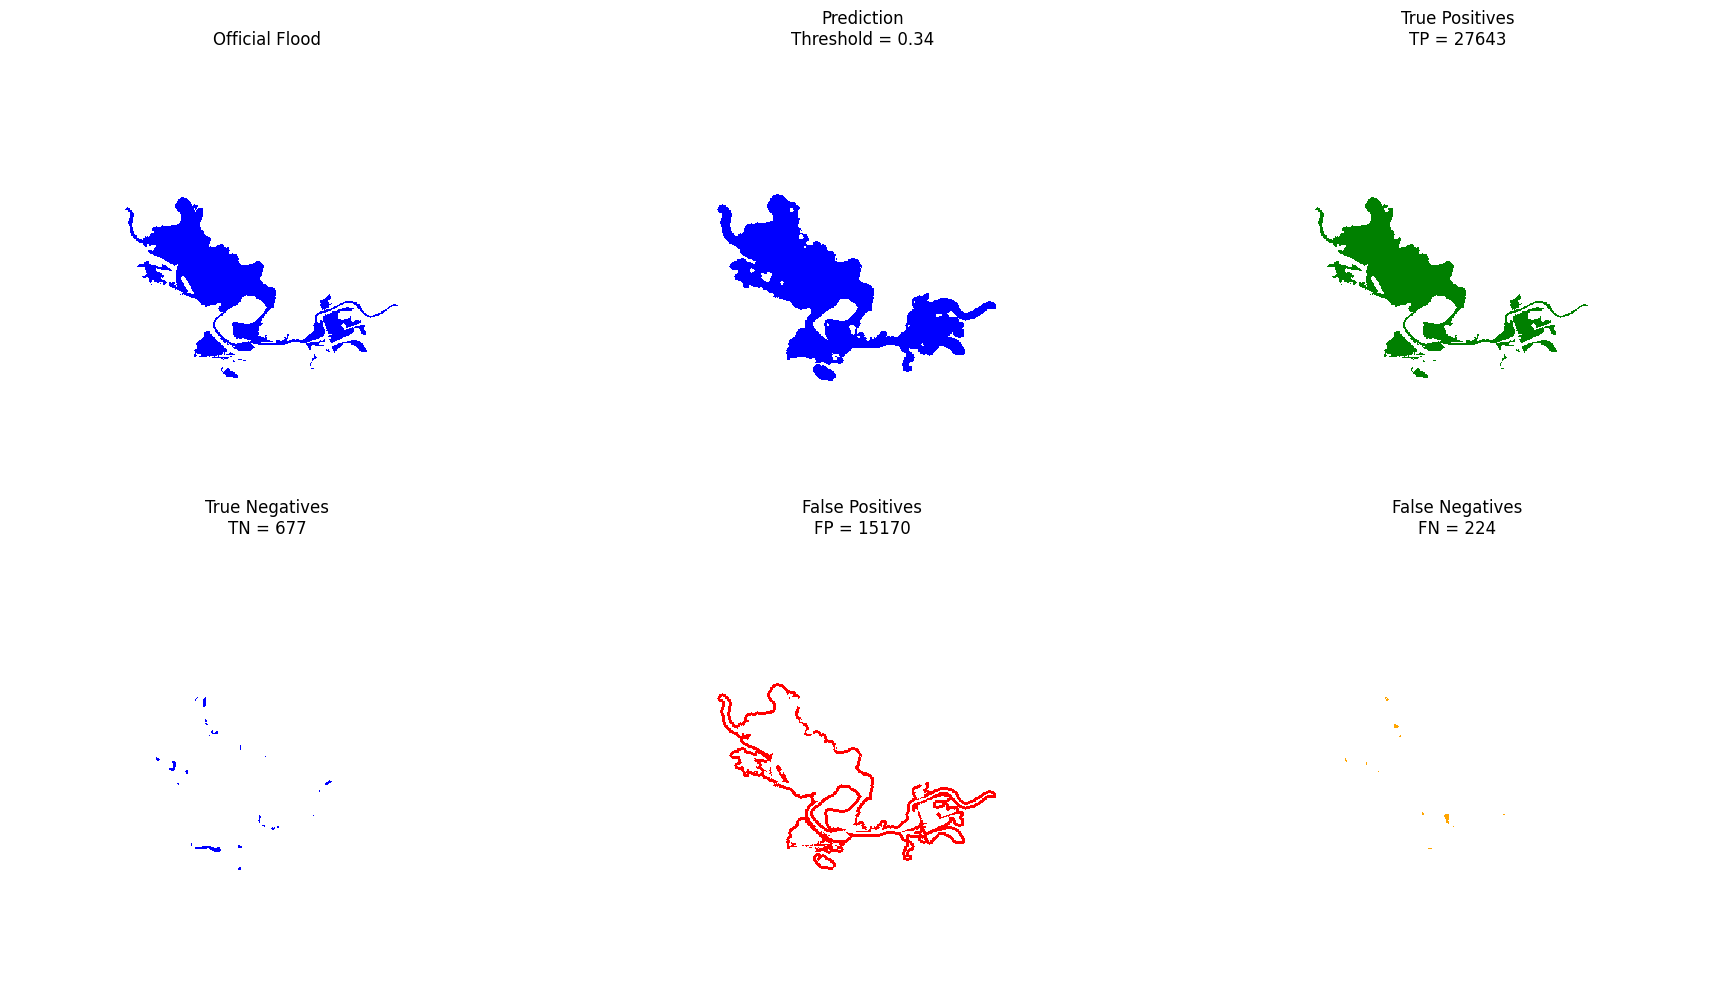

In [32]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

from scipy.ndimage import distance_transform_edt
from matplotlib.colors import ListedColormap


# --------------------------------------------------
# Paths
# --------------------------------------------------
prob_path = "/content/inference_results/sentinel1_probs.tif"

mask_path = (
    "/content/drive/MyDrive/GEEmask/Flood2025_EPSG27700_raduis20.tif"
)

image_path = (
    "/content/drive/MyDrive/GEE_Flood_Export/Sentinel1_VV_VH_Filtered_2025_EPSG27700_raduis20.tif"
)

# Select the probability threshold
threshold = 0.34


# --------------------------------------------------
# Read flood probability
# Band 2 corresponds to the flood/water class
# --------------------------------------------------
with rasterio.open(prob_path) as src:
    water_prob = src.read(2)


# --------------------------------------------------
# Read the official flood mask
# 1 = flood, 0 = non-flood
# --------------------------------------------------
with rasterio.open(mask_path) as src:
    gt = (src.read(1) > 0).astype(np.uint8)


# --------------------------------------------------
# Read Sentinel-1 data to identify valid pixels
# --------------------------------------------------
with rasterio.open(image_path) as src:
    s1 = src.read(out_dtype=np.float32)


valid_data = np.all(np.isfinite(s1), axis=0)
valid_prob = np.isfinite(water_prob)


# --------------------------------------------------
# Check dimensions
# --------------------------------------------------
if water_prob.shape != gt.shape:
    raise ValueError(
        f"Shape mismatch: probability={water_prob.shape}, "
        f"ground truth={gt.shape}"
    )

if valid_data.shape != gt.shape:
    raise ValueError(
        f"Shape mismatch: valid_data={valid_data.shape}, "
        f"ground truth={gt.shape}"
    )


# --------------------------------------------------
# Create an external 50 m buffer around the
# official flood extent
#
# Assumption: pixel resolution is approximately 10 m
# --------------------------------------------------
distance_from_flood = distance_transform_edt(
    gt == 0,
    sampling=10.0
)

evaluation_area = (
    (distance_from_flood <= 50.0)
    & valid_data
    & valid_prob
)


# --------------------------------------------------
# Convert probabilities to a binary flood map
# --------------------------------------------------
pred = (
    water_prob > threshold
).astype(np.uint8)


# --------------------------------------------------
# Confusion masks inside the evaluation area
# --------------------------------------------------
tp = (
    evaluation_area
    & (pred == 1)
    & (gt == 1)
)

tn = (
    evaluation_area
    & (pred == 0)
    & (gt == 0)
)

fp = (
    evaluation_area
    & (pred == 1)
    & (gt == 0)
)

fn = (
    evaluation_area
    & (pred == 0)
    & (gt == 1)
)


# --------------------------------------------------
# Count TP, TN, FP, and FN
# --------------------------------------------------
TP = int(tp.sum())
TN = int(tn.sum())
FP = int(fp.sum())
FN = int(fn.sum())


# --------------------------------------------------
# Calculate evaluation metrics
# --------------------------------------------------
precision = (
    TP / (TP + FP)
    if (TP + FP) > 0
    else 0.0
)

recall = (
    TP / (TP + FN)
    if (TP + FN) > 0
    else 0.0
)



f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0
    else 0.0
)

iou = (
    TP / (TP + FP + FN)
    if (TP + FP + FN) > 0
    else 0.0
)

accuracy = (
    (TP + TN) / (TP + TN + FP + FN)
    if (TP + TN + FP + FN) > 0
    else 0.0
)


# --------------------------------------------------
# Print results
# --------------------------------------------------
print("===== Official flood + 50 m buffer evaluation =====")
print("Threshold:", threshold)
print("Evaluated pixels:", int(evaluation_area.sum()))

print("\nConfusion matrix counts")
print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

print("\nMetrics")
print("Precision :", precision)
print("Recall    :", recall)
print("F1        :", f1)
print("IoU       :", iou)
print("Accuracy  :", accuracy)


# --------------------------------------------------
# Prepare maps for visualization
# Pixels outside the evaluation area are masked
# --------------------------------------------------
gt_display = np.ma.masked_where(
    ~evaluation_area,
    gt
)

pred_display = np.ma.masked_where(
    ~evaluation_area,
    pred
)

tp_display = np.ma.masked_where(
    ~tp,
    tp.astype(np.uint8)
)

tn_display = np.ma.masked_where(
    ~tn,
    tn.astype(np.uint8)
)

fp_display = np.ma.masked_where(
    ~fp,
    fp.astype(np.uint8)
)

fn_display = np.ma.masked_where(
    ~fn,
    fn.astype(np.uint8)
)


# --------------------------------------------------
# Define clear color maps
# --------------------------------------------------

# White = non-flood, blue = flood
flood_cmap = ListedColormap([
    "white",
    "blue"
])

# White background, green = TP
tp_cmap = ListedColormap([
    "white",
    "green"
])

# White background, blue = TN
tn_cmap = ListedColormap([
    "white",
    "blue"
])

# White background, red = FP
fp_cmap = ListedColormap([
    "white",
    "red"
])

# White background, orange = FN
fn_cmap = ListedColormap([
    "white",
    "orange"
])


# --------------------------------------------------
# Visualize results
# --------------------------------------------------
plt.figure(figsize=(18, 10))


# Official flood
plt.subplot(2, 3, 1)

plt.imshow(
    gt_display,
    cmap=flood_cmap,
    vmin=0,
    vmax=1,
    interpolation="nearest",
    origin="upper"
)

plt.title(
    "Official Flood\n"
)

plt.axis("off")


# Prediction
plt.subplot(2, 3, 2)

plt.imshow(
    pred_display,
    cmap=flood_cmap,
    vmin=0,
    vmax=1,
    interpolation="nearest",
    origin="upper"
)

plt.title(
    f"Prediction\n"
    f"Threshold = {threshold}\n"
)

plt.axis("off")


# True positives
plt.subplot(2, 3, 3)

plt.imshow(
    tp_display,
    cmap=tp_cmap,
    vmin=0,
    vmax=1,
    interpolation="nearest",
    origin="upper"
)

plt.title(
    f"True Positives\n"
    f"TP = {TP}\n"
)

plt.axis("off")


# True negatives
plt.subplot(2, 3, 4)

plt.imshow(
    tn_display,
    cmap=tn_cmap,
    vmin=0,
    vmax=1,
    interpolation="nearest",
    origin="upper"
)

plt.title(
    f"True Negatives\n"
    f"TN = {TN}\n"
)

plt.axis("off")


# False positives
plt.subplot(2, 3, 5)

plt.imshow(
    fp_display,
    cmap=fp_cmap,
    vmin=0,
    vmax=1,
    interpolation="nearest",
    origin="upper"
)

plt.title(
    f"False Positives\n"
    f"FP = {FP}\n"
)

plt.axis("off")


# False negatives
plt.subplot(2, 3, 6)

plt.imshow(
    fn_display,
    cmap=fn_cmap,
    vmin=0,
    vmax=1,
    interpolation="nearest",
    origin="upper"
)

plt.title(
    f"False Negatives\n"
    f"FN = {FN}\n"
)

plt.axis("off")


plt.tight_layout()
plt.show()

In [33]:
import rasterio
import numpy as np

image_path = "/content/drive/MyDrive/GEE_Flood_Export/Sentinel1_VV_VH_Filtered_2025_EPSG27700.tif"

with rasterio.open(image_path) as src:
    image = src.read(out_dtype=np.float32)

band_names = ["VV", "VH"]

for i, name in enumerate(band_names):
    band = image[i]

    valid = band[np.isfinite(band)]

    print(f"\n{name}")
    print("Minimum :", valid.min())
    print("Maximum :", valid.max())
    print("Mean    :", valid.mean())



VV
Minimum : -18.921213
Maximum : 4.6878986
Mean    : -8.858264

VH
Minimum : -26.201189
Maximum : -4.5776677
Mean    : -15.963085


In [34]:
import rasterio
import numpy as np

image_path = "/content/drive/MyDrive/GEE_Flood_Export/Sentinel1_VV_VH_Filtered_2025_EPSG27700_raduis20.tif"

with rasterio.open(image_path) as src:
    image = src.read(out_dtype=np.float32)

for i, name in enumerate(["VV", "VH"]):

    band = image[i]
    valid = band[np.isfinite(band)]

    total = valid.size

    below = np.sum(valid < -30)
    above = np.sum(valid > 10)

    print(f"\n{name}")
    print(f"Total pixels      : {total}")
    print(f"< -30 dB          : {below} ({100*below/total:.2f}%)")
    print(f"> 10 dB           : {above} ({100*above/total:.2f}%)")


VV
Total pixels      : 561694
< -30 dB          : 0 (0.00%)
> 10 dB           : 527 (0.09%)

VH
Total pixels      : 561694
< -30 dB          : 244 (0.04%)
> 10 dB           : 0 (0.00%)


In [35]:

pixel_area_m2 = 100

TP_area = TP * pixel_area_m2
TN_area = TN * pixel_area_m2
FP_area = FP * pixel_area_m2
FN_area = FN * pixel_area_m2

print(f"TP area = {TP_area:,} m²")
print(f"TN area = {TN_area:,} m²")
print(f"FP area = {FP_area:,} m²")
print(f"FN area = {FN_area:,} m²")

TP area = 2,764,300 m²
TN area = 67,700 m²
FP area = 1,517,000 m²
FN area = 22,400 m²


In [36]:
pixel_area_km2 = 0.0001  # 100 m²

print(f"TP = {TP * pixel_area_km2:.4f} km²")
print(f"TN = {TN * pixel_area_km2:.4f} km²")
print(f"FP = {FP * pixel_area_km2:.4f} km²")
print(f"FN = {FN * pixel_area_km2:.4f} km²")

TP = 2.7643 km²
TN = 0.0677 km²
FP = 1.5170 km²
FN = 0.0224 km²


In [ ]:
import os
import glob
import zipfile
import numpy as np
import rasterio
import geopandas as gpd

from rasterio.features import shapes
from shapely.geometry import shape



with rasterio.open(prob_path) as src:
    transform = src.transform
    crs = src.crs



assert pred.shape == evaluation_area.shape == fn.shape, (
   "pred, evaluation_area, and fn must have the same dimensions."
)



predicted_flood_mask = (
    np.asarray(evaluation_area, dtype=bool)
    & (np.asarray(pred) == 1)
)



fn_mask = np.asarray(fn, dtype=bool)


def mask_to_shapefile(
    binary_mask,
    output_folder,
    output_name,
    class_name
):
    os.makedirs(output_folder, exist_ok=True)

    binary_mask = np.asarray(binary_mask, dtype=bool)

    features = []

    for geometry, value in shapes(
        binary_mask.astype(np.uint8),
        mask=binary_mask,
        transform=transform,
        connectivity=8
    ):
        if int(value) == 1:
            features.append({
                "geometry": shape(geometry),
                "CLASS": class_name
            })

    if not features:
        print(f"No polygons found for {class_name}")
        return

    gdf = gpd.GeoDataFrame(
        features,
        geometry="geometry",
        crs=crs
    )


    gdf["geometry"] = gdf.geometry.buffer(0)


    gdf["AREA_M2"] = gdf.geometry.area

    shp_path = os.path.join(
        output_folder,
        output_name + ".shp"
    )

    gdf.to_file(
        shp_path,
        driver="ESRI Shapefile",
        index=False
    )

    zip_path = os.path.join(
        output_folder,
        output_name + ".zip"
    )

    with zipfile.ZipFile(
        zip_path,
        "w",
        compression=zipfile.ZIP_DEFLATED
    ) as zip_file:

        for file_path in glob.glob(
            os.path.join(output_folder, output_name + ".*")
        ):
            if not file_path.endswith(".zip"):
                zip_file.write(
                    file_path,
                    arcname=os.path.basename(file_path)
                )

    print(f"{class_name} Shapefile saved:")
    print(shp_path)
    print("ZIP:", zip_path)


mask_to_shapefile(
    binary_mask=predicted_flood_mask,
    output_folder="/content/shapefiles/predicted_flood",
    output_name="Predicted_Flood",
    class_name="Predicted"
)


mask_to_shapefile(
    binary_mask=fn_mask,
    output_folder="/content/shapefiles/false_negative",
    output_name="False_Negative",
    class_name="FN"
)

Predicted Shapefile saved:
/content/shapefiles/predicted_flood/Predicted_Flood.shp
ZIP: /content/shapefiles/predicted_flood/Predicted_Flood.zip
FN Shapefile saved:
/content/shapefiles/false_negative/False_Negative.shp
ZIP: /content/shapefiles/false_negative/False_Negative.zip


In [ ]:
import shutil
from google.colab import files

shutil.make_archive(
    "/content/Flood_Shapefiles",
    "zip",
    "/content/shapefiles"
)

files.download("/content/Flood_Shapefiles.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>